# FIBO + Neo4j — Advanced Graph Analytics & ML

This notebook performs advanced analysis on the FIBO ontology and counterparty network using:
- **Neo4j Cypher** — graph queries
- **Neo4j GDS** — PageRank, Louvain, WCC, Node Similarity, Betweenness, Node2Vec embeddings
- **APOC** — path expansion, meta-graph, triggers
- **n10s** — RDF/OWL ontology integration
- **RDFLib** — local ontology parsing & SPARQL queries
- **scikit-learn** — clustering (KMeans, DBSCAN), classification, dimensionality reduction
- **PyVis** — interactive graph visualization
- **NetworkX** — centrality, community detection

**Prereqs**: run `00_setup.cypher`, `10_load_fibo.cypher`, `25_seed_abox.cypher` first.

In [106]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from dotenv import load_dotenv
from neo4j import GraphDatabase
from pyvis.network import Network
from rdflib import Graph as RDFGraph, Namespace, URIRef
from rdflib.namespace import RDF, RDFS, OWL
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
load_dotenv()

URI  = os.getenv('NEO4J_URI', 'neo4j://127.0.0.1:7687')
USER = os.getenv('NEO4J_USER', 'neo4j')
PWD  = os.getenv('NEO4J_PASSWORD', '12345678')
DB   = os.getenv('NEO4J_DATABASE', 'neo4j')

driver = GraphDatabase.driver(URI, auth=(USER, PWD))

def q(cypher, **params):
    """Run a Cypher query and return a DataFrame."""
    with driver.session(database=DB) as s:
        return pd.DataFrame([r.data() for r in s.run(cypher, **params)])

# Verify connection
q('RETURN 1 AS ok')
print(f'Neo4j connected: {URI}')

# Check GDS availability
gds_check = q("SHOW PROCEDURES YIELD name WHERE name STARTS WITH 'gds.' RETURN count(*) AS gds_procs")
print(f'GDS procedures available: {gds_check["gds_procs"].iloc[0]}')


Neo4j connected: neo4j://127.0.0.1:7687
GDS procedures available: 473


---
## 1. RDFLib — Local Ontology Parsing & SPARQL
Fetch FIBO BE (Business Entities) ontology with RDFLib and run SPARQL queries locally.

In [76]:

# Parse FIBO Business Entities ontology directly with RDFLib
rdf_g = RDFGraph()
fibo_be_url = 'https://spec.edmcouncil.org/fibo/ontology/master/latest/BE/LegalEntities/LegalPersons.rdf'
print(f'Fetching {fibo_be_url} ...')
try:
    rdf_g.parse(fibo_be_url, format='xml')
    print(f'Loaded {len(rdf_g)} triples into RDFLib graph.\n')
except Exception as e:
    print(f'Could not fetch remote ontology: {e}')
    print('Falling back to local FIBO files...')
    import glob
    local_files = glob.glob(r'C:\Akash\Neo4j\Finology\Fibo\**\*.rdf', recursive=True)
    if local_files:
        rdf_g.parse(local_files[0], format='xml')
        print(f'Loaded {len(rdf_g)} triples from local file.')
    else:
        print('No local RDF files found. Continuing with empty RDFLib graph.')

# List all OWL classes
sparql_classes = """
SELECT ?cls ?label WHERE {
    ?cls a owl:Class .
    OPTIONAL { ?cls rdfs:label ?label }
}
ORDER BY ?label
"""
if len(rdf_g) > 0:
    results = rdf_g.query(sparql_classes, initNs={'owl': OWL, 'rdfs': RDFS})
    owl_classes = pd.DataFrame([(str(row.cls), str(row.label)) for row in results],
                               columns=['uri', 'label'])
    print(f'OWL Classes found: {len(owl_classes)}')
    display(owl_classes.head(20))
else:
    owl_classes = pd.DataFrame(columns=['uri', 'label'])
    print('No triples available — skipping SPARQL.')


Fetching https://spec.edmcouncil.org/fibo/ontology/master/latest/BE/LegalEntities/LegalPersons.rdf ...
Loaded 185 triples into RDFLib graph.

OWL Classes found: 16


,uri,label
0,https://www.omg.org/spec/Commons/Organizations...,None
1,https://www.omg.org/spec/Commons/Organizations...,None
2,N2173296e8ea445f98f82de532791cd48,None
3,https://spec.edmcouncil.org/fibo/ontology/BE/L...,business entity
4,https://spec.edmcouncil.org/fibo/ontology/BE/L...,business license
5,https://spec.edmcouncil.org/fibo/ontology/BE/L...,chartered legal person
6,https://spec.edmcouncil.org/fibo/ontology/BE/L...,legally competent natural person
7,https://spec.edmcouncil.org/fibo/ontology/BE/L...,not for profit objective
8,https://spec.edmcouncil.org/fibo/ontology/BE/L...,power of attorney
9,https://spec.edmcouncil.org/fibo/ontology/BE/L...,profit objective


In [77]:

# SPARQL: Find subclass hierarchy (rdfs:subClassOf)
hierarchy_df = pd.DataFrame(columns=['child_uri', 'child_label', 'parent_uri', 'parent_label'])
onto_G = nx.DiGraph()

if len(rdf_g) > 0:
    sparql_hierarchy = """
    SELECT ?child ?childLabel ?parent ?parentLabel WHERE {
        ?child rdfs:subClassOf ?parent .
        ?child a owl:Class .
        ?parent a owl:Class .
        OPTIONAL { ?child rdfs:label ?childLabel }
        OPTIONAL { ?parent rdfs:label ?parentLabel }
    }
    ORDER BY ?parentLabel ?childLabel
    """
    hier_results = rdf_g.query(sparql_hierarchy, initNs={'owl': OWL, 'rdfs': RDFS})
    hierarchy_df = pd.DataFrame(
        [(str(r.child), str(r.childLabel), str(r.parent), str(r.parentLabel)) for r in hier_results],
        columns=['child_uri', 'child_label', 'parent_uri', 'parent_label']
    )
    print(f'SubClassOf relationships: {len(hierarchy_df)}')
    display(hierarchy_df.head(15))

    # Build a NetworkX graph from the ontology hierarchy
    for _, row in hierarchy_df.iterrows():
        child = row['child_label'] if row['child_label'] != 'None' else row['child_uri'].split('/')[-1]
        parent = row['parent_label'] if row['parent_label'] != 'None' else row['parent_uri'].split('/')[-1]
        onto_G.add_edge(child, parent)

    print(f'\nOntology hierarchy graph: {onto_G.number_of_nodes()} classes, {onto_G.number_of_edges()} edges')
else:
    print('Skipped — no RDFLib triples loaded.')


SubClassOf relationships: 7


,child_uri,child_label,parent_uri,parent_label
0,https://spec.edmcouncil.org/fibo/ontology/BE/L...,chartered legal person,https://www.omg.org/spec/Commons/Organizations...,None
1,https://spec.edmcouncil.org/fibo/ontology/BE/L...,legally competent natural person,https://www.omg.org/spec/Commons/Organizations...,None
2,https://spec.edmcouncil.org/fibo/ontology/BE/L...,statutory body,https://www.omg.org/spec/Commons/Organizations...,None
3,https://spec.edmcouncil.org/fibo/ontology/BE/L...,variable interest entity,https://www.omg.org/spec/Commons/Organizations...,None
4,https://spec.edmcouncil.org/fibo/ontology/BE/L...,special purpose vehicle,https://www.omg.org/spec/Commons/Organizations...,None
5,https://spec.edmcouncil.org/fibo/ontology/BE/L...,fonds commun de placement,https://www.omg.org/spec/Commons/Organizations...,None
6,https://spec.edmcouncil.org/fibo/ontology/BE/L...,religious objective,https://spec.edmcouncil.org/fibo/ontology/BE/L...,not for profit objective



Ontology hierarchy graph: 10 classes, 7 edges


In [78]:

# SPARQL: Object properties with domain/range
if len(rdf_g) > 0:
    sparql_props = """
    SELECT ?prop ?propLabel ?domain ?domainLabel ?range ?rangeLabel WHERE {
        ?prop a owl:ObjectProperty .
        OPTIONAL { ?prop rdfs:label ?propLabel }
        OPTIONAL { ?prop rdfs:domain ?domain . ?domain rdfs:label ?domainLabel }
        OPTIONAL { ?prop rdfs:range ?range . ?range rdfs:label ?rangeLabel }
    }
    ORDER BY ?propLabel
    """
    prop_results = rdf_g.query(sparql_props, initNs={'owl': OWL, 'rdfs': RDFS})
    props_df = pd.DataFrame(
        [(str(r.propLabel), str(r.domainLabel), str(r.rangeLabel)) for r in prop_results],
        columns=['property', 'domain', 'range']
    )
    print(f'Object Properties: {len(props_df)}')
    display(props_df)
else:
    print('Skipped — no RDFLib triples loaded.')


Object Properties: 2


,property,domain,range
0,None,None,None
1,has intended liquidation date,None,None


---
## 2. n10s — Verify Neo4j Ontology Graph & Map RDF to Property Graph
Check how n10s mapped the FIBO ontology into Neo4j labels, relationships, and properties.

In [79]:

# n10s graph config
n10s_config = q('CALL n10s.graphconfig.show()')
print('n10s Graph Configuration:')
display(n10s_config)

# n10s mapping preview: which RDF types became Neo4j labels?
n10s_mapping = q("""
MATCH (c:Class)
RETURN coalesce(c.label, c.name, 'unnamed') AS class_name,
       c.uri AS full_uri,
       size([(c)<-[:SCO]-(sub) | sub]) AS direct_subclasses,
       size([(c)-[:DOMAIN]-(prop) | prop]) AS properties_in_domain
ORDER BY direct_subclasses DESC
LIMIT 25
""")
print(f'\nTop 25 FIBO classes by direct subclass count:')
display(n10s_mapping)


n10s Graph Configuration:


,param,value
0,handleVocabUris,IGNORE
1,handleMultival,ARRAY
2,handleRDFTypes,LABELS
3,keepLangTag,False
4,keepCustomDataTypes,False
5,applyNeo4jNaming,True
6,baseSchemaNamespace,neo4j://graph.schema#
7,baseSchemaPrefix,n4sch
8,classLabel,Class
9,subClassOfRel,SCO



Top 25 FIBO classes by direct subclass count:


,class_name,full_uri,direct_subclasses,properties_in_domain
0,LegalEntity,https://www.omg.org/spec/Commons/Organizations...,4,5
1,LegalPerson,https://www.omg.org/spec/Commons/Organizations...,2,1
2,[relationship qualifier],https://spec.edmcouncil.org/fibo/ontology/BE/L...,1,0
3,BusinessObjective,https://spec.edmcouncil.org/fibo/ontology/FND/...,1,0
4,OrganizationIdentifier,https://www.omg.org/spec/Commons/Organizations...,1,0
5,License,https://spec.edmcouncil.org/fibo/ontology/FND/...,1,0
6,[not for profit objective],https://spec.edmcouncil.org/fibo/ontology/BE/L...,1,0
7,[public purpose],https://spec.edmcouncil.org/fibo/ontology/BE/L...,0,0
8,[profit objective],https://spec.edmcouncil.org/fibo/ontology/BE/L...,0,0
9,Date,https://www.omg.org/spec/Commons/DatesAndTimes...,0,0


In [80]:
# APOC meta-graph: high-level schema overview
meta = q("""
CALL apoc.meta.stats() YIELD labels, relTypes, propertyKeyCount, nodeCount, relCount
RETURN labels, relTypes, propertyKeyCount, nodeCount, relCount
""")
print('=== Database Meta Stats ===')
print(f'  Total nodes: {meta["nodeCount"].iloc[0]}')
print(f'  Total relationships: {meta["relCount"].iloc[0]}')
print(f'  Property keys: {meta["propertyKeyCount"].iloc[0]}')
print(f'\nLabels: {meta["labels"].iloc[0]}')
print(f'\nRelationship Types: {meta["relTypes"].iloc[0]}')

=== Database Meta Stats ===
  Total nodes: 895
  Total relationships: 2156
  Property keys: 176

Labels: {'LegalEntity': 21, 'Bank': 2, 'Ontology': 16, 'Regulator': 4, 'SeedRegulator': 4, 'Property': 6, 'DatatypeProperty': 15, 'ObjectProperty': 81, 'SeedSector': 7, 'Sector': 7, 'Resource': 857, 'Holding': 3, 'RelationshipPeriodQualifier': 2, 'SymmetricProperty': 1, 'LegalEntityIdentifierScheme': 1, 'EntityLegalFormScheme': 1, 'RelationshipStatus': 2, 'SeedJurisdiction': 5, 'Jurisdiction': 5, 'Corporation': 21, 'Restriction': 226, 'AnnotationProperty': 5, 'Relationship': 32, 'AccountingFramework': 3, 'MaturityLevel': 3, 'Class': 237, 'NamedIndividual': 12, '_GraphConfig': 1}

Relationship Types: {'()-[:ONEOF]->(:Resource)': 1, '()-[:OPERATES_IN]->(:SeedSector)': 21, '()-[:DOMAIN]->(:Class)': 29, '(:AnnotationProperty)-[:ISDEFINEDBY]->()': 5, '(:AccountingFramework)-[:SEEALSO]->()': 3, '()-[:PROPERTYCHAINAXIOM]->()': 4, '()-[:OPERATES_IN_JURISDICTION]->()': 4, '()-[:HASMATURITYLEVEL]->()

---
## 3. APOC Path Expansion — Control Chain Visualization
Use APOC's `expandConfig` to trace all control chains from holding companies.

In [81]:
# APOC path expander: find all paths from holding companies
control_paths = q("""
MATCH (h:Holding)
CALL apoc.path.expandConfig(h, {
    relationshipFilter: 'HAS_OWNERSHIP_IN>|HAS_CONTROLLING_PARTY>',
    minLevel: 1,
    maxLevel: 5,
    uniqueness: 'NODE_GLOBAL'
}) YIELD path
WITH h, last(nodes(path)) AS terminus, length(path) AS depth,
     [n IN nodes(path) | n.name] AS chain
RETURN h.name AS holding, terminus.name AS terminus_entity,
       depth, chain
ORDER BY holding, depth DESC
""")
print(f'Control chains found: {len(control_paths)}')
display(control_paths)

Control chains found: 20


,holding,terminus_entity,depth,chain
0,Apex Holdings Inc.,Vanta Insurance GmbH,3,"[Apex Holdings Inc., Apex Offshore Ltd, Apex I..."
1,Apex Holdings Inc.,Helios Renewables Plc,2,"[Apex Holdings Inc., Apex Energy Plc, Helios R..."
2,Apex Holdings Inc.,Apex Realty Pte Ltd,2,"[Apex Holdings Inc., Apex Offshore Ltd, Apex R..."
3,Apex Holdings Inc.,Apex Insurance Ltd,2,"[Apex Holdings Inc., Apex Offshore Ltd, Apex I..."
4,Apex Holdings Inc.,Apex Capital LLC,1,"[Apex Holdings Inc., Apex Capital LLC]"
5,Apex Holdings Inc.,Apex Energy Plc,1,"[Apex Holdings Inc., Apex Energy Plc]"
6,Apex Holdings Inc.,Apex Tech GmbH,1,"[Apex Holdings Inc., Apex Tech GmbH]"
7,Apex Holdings Inc.,Apex Offshore Ltd,1,"[Apex Holdings Inc., Apex Offshore Ltd]"
8,Apex Offshore Ltd,Helios Renewables Plc,3,"[Apex Offshore Ltd, Apex Holdings Inc., Apex E..."
9,Apex Offshore Ltd,Vanta Insurance GmbH,2,"[Apex Offshore Ltd, Apex Insurance Ltd, Vanta ..."


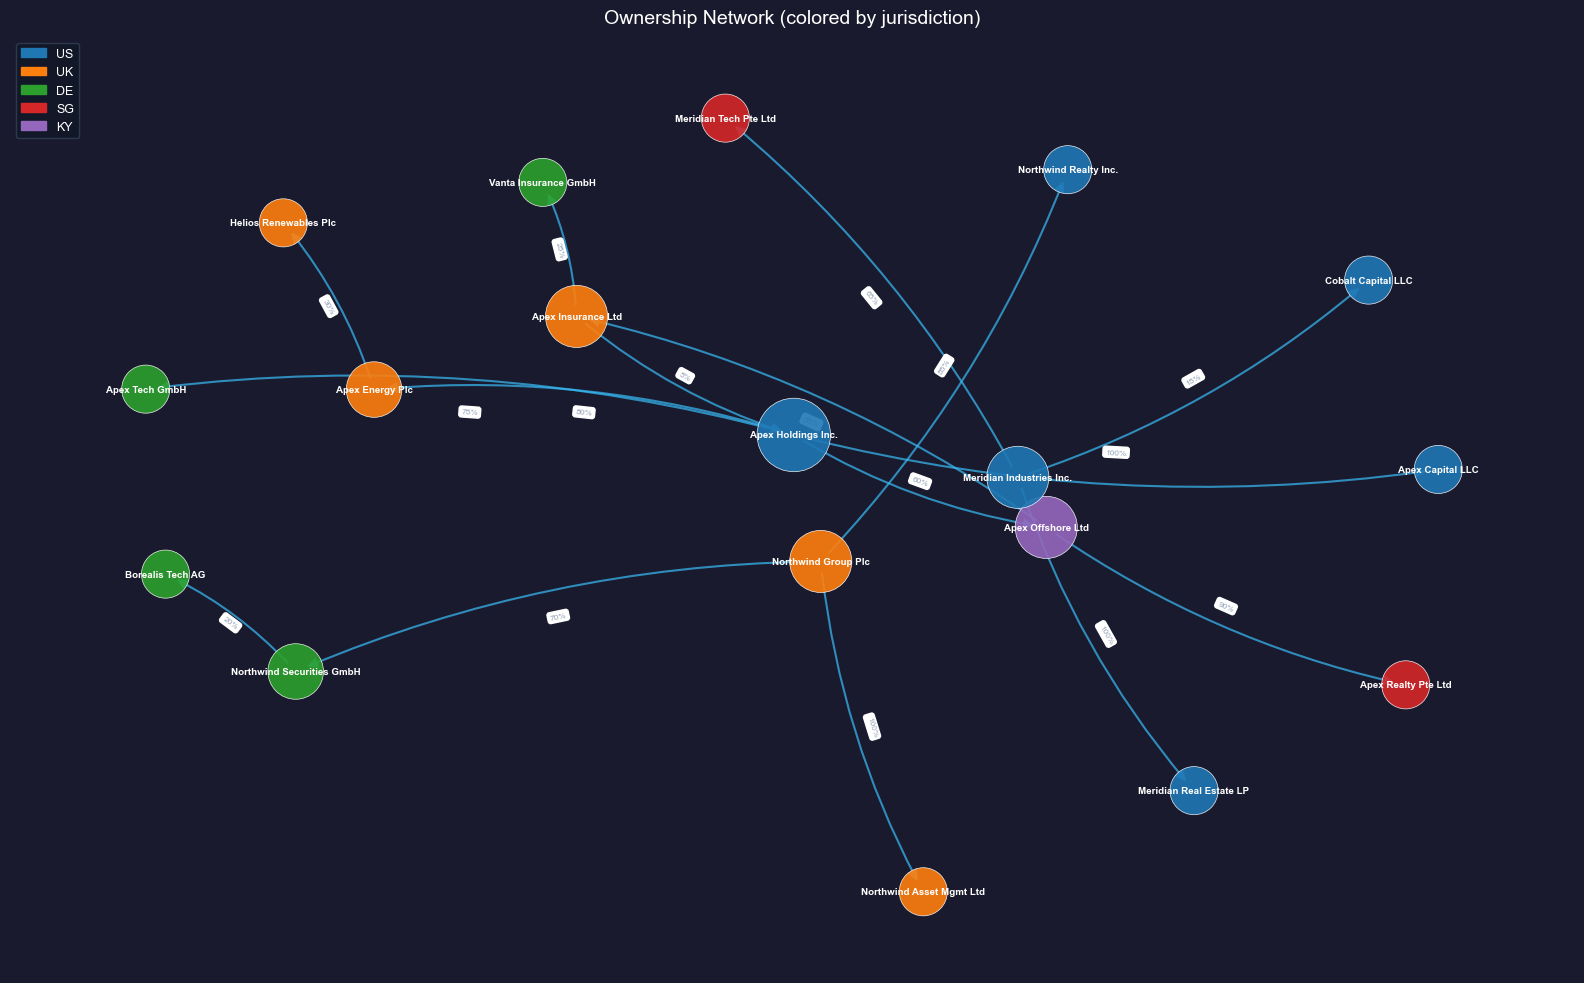

In [82]:
# Ownership Network — NetworkX + Matplotlib (renders natively in VS Code)
ownership_edges = q("""
MATCH (a:LegalEntity)-[r:HAS_OWNERSHIP_IN]->(b:LegalEntity)
RETURN a.name AS src, b.name AS dst, r.percent AS pct,
       a.jurisdictionCode AS src_juris, b.jurisdictionCode AS dst_juris
""")

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

G_own = nx.DiGraph()
juris_colors = {'US': '#1f77b4', 'UK': '#ff7f0e', 'DE': '#2ca02c',
                'SG': '#d62728', 'KY': '#9467bd'}
node_juris = {}
for _, row in ownership_edges.iterrows():
    node_juris[row['src']] = row['src_juris']
    node_juris[row['dst']] = row['dst_juris']
    G_own.add_edge(row['src'], row['dst'], weight=row['pct'])

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_facecolor('#1a1a2e')
fig.set_facecolor('#1a1a2e')

pos = nx.spring_layout(G_own, k=2.5, iterations=80, seed=42)
node_colors = [juris_colors.get(node_juris.get(n, ''), '#aaaaaa') for n in G_own.nodes()]
node_sizes = [800 + G_own.degree(n) * 400 for n in G_own.nodes()]

nx.draw_networkx_nodes(G_own, pos, node_color=node_colors, node_size=node_sizes,
                       alpha=0.9, edgecolors='white', linewidths=0.5, ax=ax)
nx.draw_networkx_labels(G_own, pos, font_size=7, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G_own, pos, edge_color='#38bdf8', alpha=0.7, width=1.5,
                       arrows=True, arrowsize=15, connectionstyle='arc3,rad=0.1', ax=ax)
edge_labels = {(u,v): f"{d['weight']}%" for u,v,d in G_own.edges(data=True)}
nx.draw_networkx_edge_labels(G_own, pos, edge_labels=edge_labels,
                             font_size=6, font_color='#94a3b8', ax=ax)

legend_patches = [mpatches.Patch(color=c, label=k) for k,c in juris_colors.items()]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9,
          facecolor='#111827', edgecolor='#334155', labelcolor='white')
ax.set_title('Ownership Network (colored by jurisdiction)', color='white', fontsize=14, pad=10)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 4. GDS — Graph Projection & Algorithms
Project the counterparty graph into GDS and run multiple algorithms.

In [83]:
# Drop existing projection if present
try:
    q("CALL gds.graph.drop('counterparty_ml') YIELD graphName RETURN graphName")
    print('Dropped existing projection.')
except:
    pass

# Project the graph via Cypher (include all entity relationship types)
stats = q("""
CALL gds.graph.project(
  'counterparty_ml',
  ['LegalEntity','Bank','Holding','Corporation'],
  {
    HAS_OWNERSHIP_IN:      { orientation: 'NATURAL', properties: ['weight'] },
    HAS_CONTROLLING_PARTY: { orientation: 'NATURAL' },
    LENDS_TO:              { orientation: 'NATURAL', properties: ['exposure_musd'] },
    SUPPLIES_TO:           { orientation: 'NATURAL' },
    JOINT_VENTURE:         { orientation: 'NATURAL' }
  }
) YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")
print(f'Projected graph: {stats["nodeCount"].iloc[0]} nodes, {stats["relationshipCount"].iloc[0]} relationships')

Dropped existing projection.
Projected graph: 21 nodes, 44 relationships


=== PageRank (Systemic Importance) ===


,name,score
0,Apex Holdings Inc.,0.8768
1,Northwind Group Plc,0.5325
2,Apex Offshore Ltd,0.4050
3,Meridian Industries Inc.,0.4050
4,Apex Capital LLC,0.1500
5,Apex Energy Plc,0.1500
6,Apex Tech GmbH,0.1500
7,Apex Realty Pte Ltd,0.1500
8,Apex Insurance Ltd,0.1500
9,Northwind Asset Mgmt Ltd,0.1500


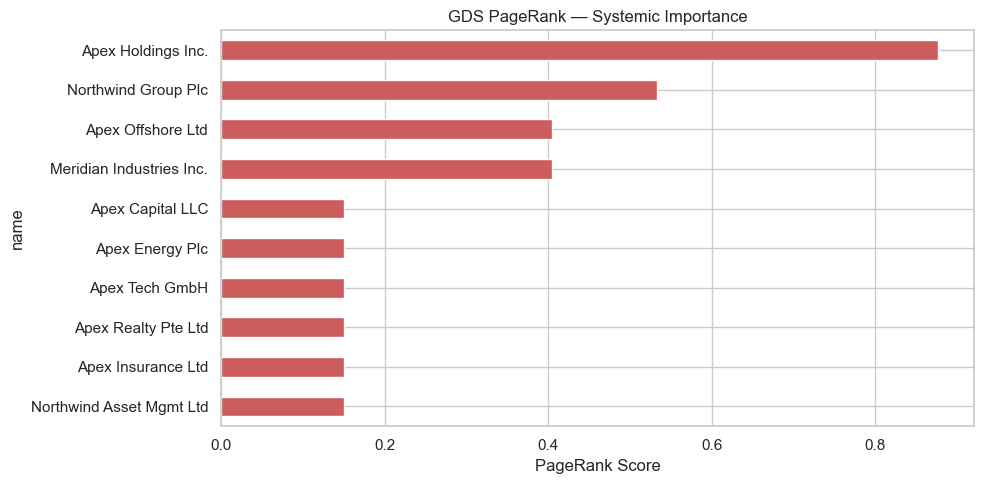

In [84]:

# 4.1 PageRank — systemic importance
pagerank_df = q("""
CALL gds.pageRank.stream('counterparty_ml', {
    relationshipTypes: ['HAS_CONTROLLING_PARTY'],
    maxIterations: 30,
    dampingFactor: 0.85
}) YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS n, score
RETURN n.name AS name, round(score * 10000) / 10000 AS score
ORDER BY score DESC
""")
print('=== PageRank (Systemic Importance) ===')
display(pagerank_df.head(15))

pagerank_df.head(10).plot.barh(x='name', y='score', color='indianred', legend=False, figsize=(10, 5))
plt.gca().invert_yaxis(); plt.title('GDS PageRank — Systemic Importance')
plt.xlabel('PageRank Score'); plt.tight_layout(); plt.show()


In [85]:

# 4.2 Louvain Community Detection
louvain_df = q("""
CALL gds.louvain.stream('counterparty_ml', {
    relationshipTypes: ['HAS_OWNERSHIP_IN'],
    relationshipWeightProperty: 'weight'
}) YIELD nodeId, communityId
WITH gds.util.asNode(nodeId) AS n, communityId
RETURN n.name AS name, communityId
ORDER BY communityId, name
""")
print(f'=== Louvain Communities: {louvain_df["communityId"].nunique()} detected ===')

for cid, group in louvain_df.groupby('communityId'):
    members = group['name'].tolist()
    print(f'  Community {cid}: {members}')


=== Louvain Communities: 7 detected ===
  Community 11: ['Sentinel Bank N.A.']
  Community 12: ['Pacifica Trust Bank']
  Community 16: ['Apex Capital LLC', 'Apex Energy Plc', 'Apex Holdings Inc.', 'Apex Tech GmbH', 'Helios Renewables Plc']
  Community 17: ['Borealis Tech AG', 'Northwind Asset Mgmt Ltd', 'Northwind Group Plc', 'Northwind Realty Inc.', 'Northwind Securities GmbH']
  Community 18: ['Lotus Properties Pte Ltd']
  Community 19: ['Cobalt Capital LLC', 'Meridian Industries Inc.', 'Meridian Real Estate LP', 'Meridian Tech Pte Ltd']
  Community 20: ['Apex Insurance Ltd', 'Apex Offshore Ltd', 'Apex Realty Pte Ltd', 'Vanta Insurance GmbH']


---
## 4.2b Why Does Apex Holdings Have the Highest PageRank? — Louvain + PageRank Combined

### Understanding PageRank in a Control Graph

PageRank here was run **only on `HAS_CONTROLLING_PARTY` edges** — not ownership percentage or financial size.
It answers: *"If influence flows down the control chain, which entity is most central?"*

A high score does **NOT** mean:
- Apex Holdings is the richest or most profitable
- It has the most employees or revenue

It **DOES** mean:
- Many other entities depend on it (directly or indirectly)
- It sits at the top of a control hierarchy that spans many subsidiaries
- If it defaults or is disrupted, the cascade through the network is widest

### The Combination: Louvain + PageRank
By merging community labels with PageRank scores we can find the **"risk champion"** of each community — the single entity whose failure would most disrupt its corporate group. This is directly useful for:
- **Stress testing**: which entity to shock first in each group?
- **Regulatory oversight**: which entity needs the most monitoring per conglomerate?
- **M&A analysis**: which entity is the true "control hub" of each group?


=== Risk Champions — Most Influential Entity per Corporate Group ===

  Community 16: 👑 Apex Holdings Inc. (PageRank=0.8768)
             group also contains: Apex Capital LLC, Apex Energy Plc, Apex Tech GmbH, Helios Renewables Plc

  Community 17: 👑 Northwind Group Plc (PageRank=0.5325)
             group also contains: Borealis Tech AG, Northwind Asset Mgmt Ltd, Northwind Realty Inc., Northwind Securities GmbH

  Community 19: 👑 Meridian Industries Inc. (PageRank=0.4050)
             group also contains: Cobalt Capital LLC, Meridian Real Estate LP, Meridian Tech Pte Ltd

  Community 20: 👑 Apex Offshore Ltd (PageRank=0.4050)
             group also contains: Apex Insurance Ltd, Apex Realty Pte Ltd, Vanta Insurance GmbH

  Community 11: 👑 Sentinel Bank N.A. (PageRank=0.1500)
             group also contains: 

  Community 12: 👑 Pacifica Trust Bank (PageRank=0.1500)
             group also contains: 

  Community 18: 👑 Lotus Properties Pte Ltd (PageRank=0.1500)
             group also c

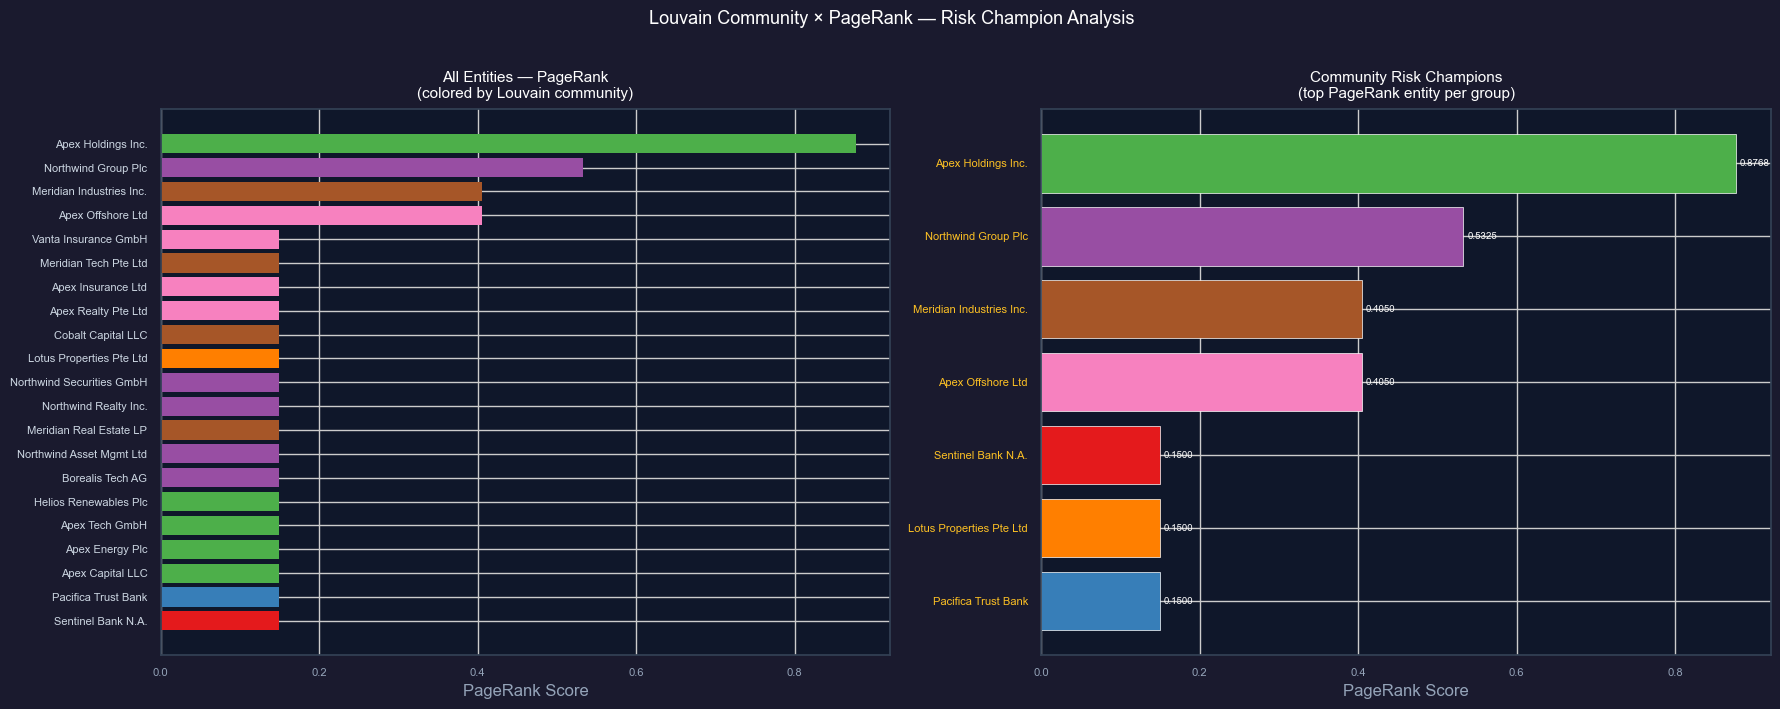


=== Why does Apex Holdings Inc. score 0.8768? ===

PageRank was run on HAS_CONTROLLING_PARTY edges with dampingFactor=0.85.
An entity scores high if: (a) many others point to it, AND (b) those pointers are themselves important.

  Direct control/ownership:
    Apex Holdings  ─[HAS_OWNERSHIP_IN]─▶  Apex Capital LLC (100%)
    Apex Holdings  ─[HAS_OWNERSHIP_IN]─▶  Apex Energy Plc (80%)
    Apex Holdings  ─[HAS_OWNERSHIP_IN]─▶  Apex Tech GmbH (75%)
    Apex Holdings  ─[HAS_OWNERSHIP_IN]─▶  Apex Offshore Ltd (60%)

  Indirect reach (2 hops): 4 additional entities
    → Apex Holdings Inc.
    → Helios Renewables Plc
    → Apex Realty Pte Ltd
    → Apex Insurance Ltd

  Conclusion: Apex Holdings sits at the TOP of the largest control hierarchy.
  Its score is high NOT because it is "richer" — but because it CONTROLS the
  most entities, and those entities themselves control others. PageRank treats
  control like a vote: controlling an important subsidiary is worth more than
  controlling a 

In [107]:

# 4.2b Louvain + PageRank: Find the most influential entity per community
# Key risk analysis pattern: "who is the control hub of each corporate group?"

# ── Step 1: Merge community labels with PageRank scores ──
combined = louvain_df.merge(
    pagerank_df.rename(columns={'score': 'pagerank'}),
    on='name', how='left'
).fillna(0)

# ── Step 2: Find the "risk champion" — max PageRank entity per community ──
champions = (
    combined.loc[combined.groupby('communityId')['pagerank'].idxmax()]
    .reset_index(drop=True)
    .sort_values('pagerank', ascending=False)
)

print('=== Risk Champions — Most Influential Entity per Corporate Group ===')
print()
for _, row in champions.iterrows():
    members = combined[combined['communityId'] == row['communityId']]['name'].tolist()
    members_str = ', '.join(m for m in members if m != row['name'])
    print(f"  Community {int(row['communityId'])}: 👑 {row['name']} (PageRank={row['pagerank']:.4f})")
    print(f"             group also contains: {members_str}")
    print()

# ── Step 3: Visualize — side-by-side chart ──
comm_colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628','#f781bf','#999999']
unique_comms = sorted(combined['communityId'].unique())
comm_to_idx  = {c: i for i, c in enumerate(unique_comms)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#1a1a2e')

for ax in axes:
    ax.set_facecolor('#0f172a')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')

# Left chart: every entity, colored by community, sorted by PageRank
combined_sorted = combined.sort_values('pagerank', ascending=True)
bar_colors_left = [comm_colors[comm_to_idx[c] % len(comm_colors)]
                   for c in combined_sorted['communityId']]

bars = axes[0].barh(combined_sorted['name'], combined_sorted['pagerank'],
                    color=bar_colors_left, edgecolor='none')
axes[0].set_xlabel('PageRank Score', color='#94a3b8')
axes[0].set_title('All Entities — PageRank\n(colored by Louvain community)', fontsize=11, pad=8)
axes[0].tick_params(axis='y', labelsize=8, colors='#cbd5e1')
axes[0].tick_params(axis='x', labelsize=8, colors='#94a3b8')

# Right chart: champion per community only
champ_colors = [comm_colors[comm_to_idx[c] % len(comm_colors)]
                for c in champions['communityId']]
champ_sorted = champions.sort_values('pagerank', ascending=True)
champ_colors_sorted = [comm_colors[comm_to_idx[c] % len(comm_colors)]
                       for c in champ_sorted['communityId']]

bars2 = axes[1].barh(champ_sorted['name'], champ_sorted['pagerank'],
                     color=champ_colors_sorted, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('PageRank Score', color='#94a3b8')
axes[1].set_title('Community Risk Champions\n(top PageRank entity per group)', fontsize=11, pad=8)
axes[1].tick_params(axis='y', labelsize=8, colors='#fbbf24')
axes[1].tick_params(axis='x', labelsize=8, colors='#94a3b8')

# Add value labels
for bar in bars2:
    w = bar.get_width()
    axes[1].text(w + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{w:.4f}', va='center', fontsize=7, color='white')

plt.suptitle('Louvain Community × PageRank — Risk Champion Analysis',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Step 4: Explain WHY Apex Holdings has the highest score ──
print()
print('=== Why does Apex Holdings Inc. score 0.8768? ===')
print()
print('PageRank was run on HAS_CONTROLLING_PARTY edges with dampingFactor=0.85.')
print('An entity scores high if: (a) many others point to it, AND (b) those pointers are themselves important.')
print()

# Trace the direct control chain
apex_direct = q("""
MATCH (apex:LegalEntity {name: 'Apex Holdings Inc.'})-[r:HAS_CONTROLLING_PARTY|HAS_OWNERSHIP_IN]->(sub:LegalEntity)
RETURN sub.name AS subsidiary, type(r) AS relationship, r.percent AS ownership_pct
ORDER BY r.percent DESC
""")

apex_indirect = q("""
MATCH (apex:LegalEntity {name: 'Apex Holdings Inc.'})-[:HAS_CONTROLLING_PARTY|HAS_OWNERSHIP_IN*2]->(sub:LegalEntity)
RETURN DISTINCT sub.name AS indirect_entity
""")

print(f'  Direct control/ownership:')
for _, row in apex_direct.iterrows():
    pct = f" ({int(row['ownership_pct'])}%)" if row['ownership_pct'] else ''
    print(f'    Apex Holdings  ─[{row["relationship"]}]─▶  {row["subsidiary"]}{pct}')

print(f'\n  Indirect reach (2 hops): {len(apex_indirect)} additional entities')
for _, row in apex_indirect.iterrows():
    print(f'    → {row["indirect_entity"]}')

print()
print('  Conclusion: Apex Holdings sits at the TOP of the largest control hierarchy.')
print('  Its score is high NOT because it is "richer" — but because it CONTROLS the')
print('  most entities, and those entities themselves control others. PageRank treats')
print('  control like a vote: controlling an important subsidiary is worth more than')
print('  controlling a small isolated entity.')
print()
print('  Risk implication: If Apex Holdings defaults, its subsidiaries lose their')
print('  parent — potentially triggering cross-defaults, covenant breaches, and')
print('  forced asset sales across the ENTIRE corporate group.')


In [86]:

# 4.3 Weakly Connected Components
wcc_df = q("""
CALL gds.wcc.stream('counterparty_ml', {
    relationshipTypes: ['HAS_OWNERSHIP_IN', 'HAS_CONTROLLING_PARTY']
}) YIELD nodeId, componentId
WITH gds.util.asNode(nodeId) AS n, componentId
RETURN n.name AS name, componentId
ORDER BY componentId, name
""")
print(f'=== WCC: {wcc_df["componentId"].nunique()} components ===')

wcc_summary = wcc_df.groupby('componentId').agg(
    size=('name', 'count'),
    members=('name', lambda x: list(x)[:8])
).sort_values('size', ascending=False)
display(wcc_summary)


=== WCC: 6 components ===


,size,members
componentId,,
0,9,"[Apex Capital LLC, Apex Energy Plc, Apex Holdi..."
7,5,"[Borealis Tech AG, Northwind Asset Mgmt Ltd, N..."
13,4,"[Cobalt Capital LLC, Meridian Industries Inc.,..."
11,1,[Sentinel Bank N.A.]
12,1,[Pacifica Trust Bank]
18,1,[Lotus Properties Pte Ltd]


=== Betweenness Centrality (Top 10) ===


,name,betweenness
0,Meridian Industries Inc.,154.0
1,Cobalt Capital LLC,123.5
2,Apex Holdings Inc.,122.5
3,Sentinel Bank N.A.,122.5
4,Northwind Group Plc,102.5
5,Apex Offshore Ltd,89.5
6,Meridian Tech Pte Ltd,85.5
7,Northwind Securities GmbH,74.0
8,Borealis Tech AG,69.5
9,Apex Energy Plc,63.0


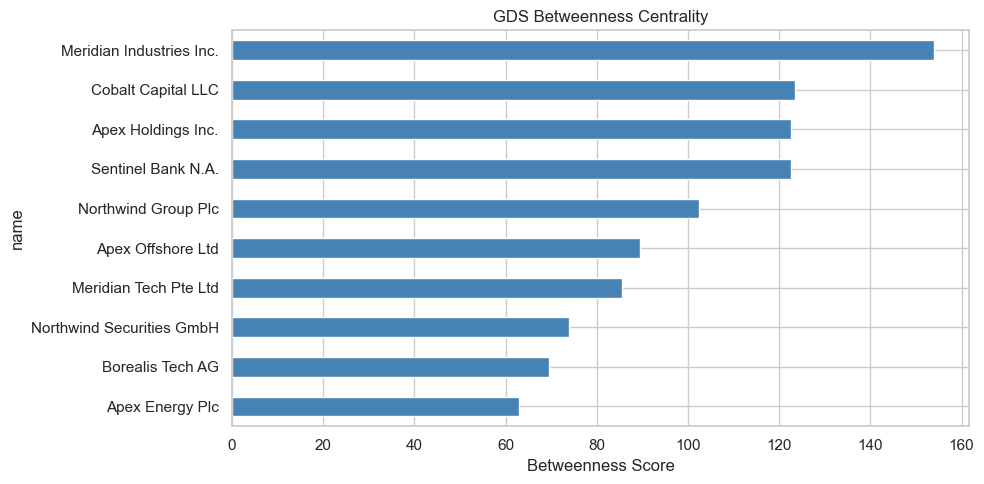

In [87]:

# 4.4 Betweenness Centrality
between_df = q("""
CALL gds.betweenness.stream('counterparty_ml') YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS n, score
RETURN n.name AS name, round(score * 1000) / 1000 AS betweenness
ORDER BY betweenness DESC
""")
print('=== Betweenness Centrality (Top 10) ===')
display(between_df.head(10))

between_df.head(10).plot.barh(x='name', y='betweenness', color='steelblue', legend=False, figsize=(10, 5))
plt.gca().invert_yaxis(); plt.title('GDS Betweenness Centrality')
plt.xlabel('Betweenness Score'); plt.tight_layout(); plt.show()


In [88]:

# 4.5 Node Similarity (Jaccard)
nodesim_df = q("""
CALL gds.nodeSimilarity.stream('counterparty_ml', {
    similarityCutoff: 0.1,
    topK: 5
}) YIELD node1, node2, similarity
WITH gds.util.asNode(node1) AS a, gds.util.asNode(node2) AS b, similarity
RETURN a.name AS entity1, b.name AS entity2, round(similarity * 1000) / 1000 AS similarity
ORDER BY similarity DESC
LIMIT 20
""")
print('=== Node Similarity (Jaccard) ===')
display(nodesim_df)


=== Node Similarity (Jaccard) ===


,entity1,entity2,similarity
0,Meridian Tech Pte Ltd,Meridian Real Estate LP,1.0
1,Northwind Asset Mgmt Ltd,Vanta Insurance GmbH,1.0
2,Northwind Realty Inc.,Northwind Asset Mgmt Ltd,1.0
3,Vanta Insurance GmbH,Northwind Realty Inc.,1.0
4,Apex Tech GmbH,Apex Capital LLC,1.0
5,Northwind Asset Mgmt Ltd,Northwind Realty Inc.,1.0
6,Vanta Insurance GmbH,Northwind Asset Mgmt Ltd,1.0
7,Meridian Real Estate LP,Meridian Tech Pte Ltd,1.0
8,Northwind Realty Inc.,Vanta Insurance GmbH,1.0
9,Apex Capital LLC,Apex Tech GmbH,1.0


---
## 5. GDS Node2Vec — Graph Embeddings for ML
Generate node embeddings using Node2Vec and apply ML algorithms.

In [89]:

# 5.1 Node2Vec — graph embeddings
embedding_df = q("""
CALL gds.node2vec.stream('counterparty_ml', {
    embeddingDimension: 16,
    walkLength: 10,
    walksPerNode: 5,
    inOutFactor: 1.0,
    returnFactor: 1.0
}) YIELD nodeId, embedding
WITH gds.util.asNode(nodeId) AS n, embedding
RETURN n.name AS name, embedding
""")
print(f'Node2Vec embeddings generated for {len(embedding_df)} entities')
embedding_df.head()


Node2Vec embeddings generated for 21 entities


,name,embedding
0,Apex Holdings Inc.,"[0.0004165034624747932, 0.018355412408709526, ..."
1,Apex Capital LLC,"[0.0006452991510741413, 0.01029204297810793, -..."
2,Apex Energy Plc,"[0.0004950331058353186, 0.02119569294154644, 0..."
3,Apex Tech GmbH,"[0.000480058544781059, -0.010470939800143242, ..."
4,Apex Realty Pte Ltd,"[0.0005590128130279481, -0.001004110206849873,..."


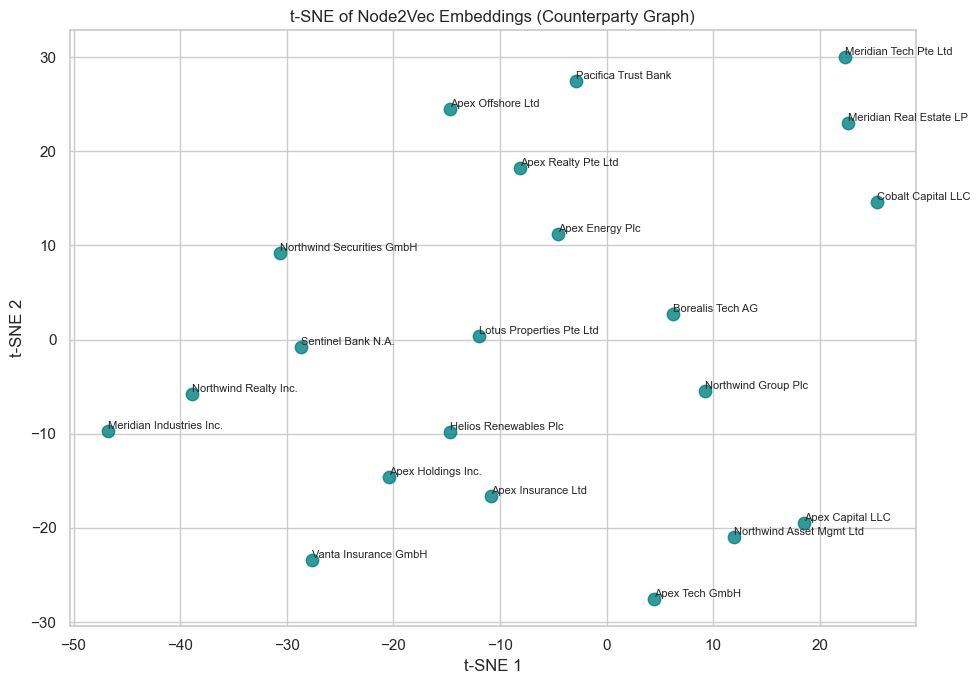

In [90]:

# 5.2 t-SNE dimensionality reduction + visualization
embeddings_matrix = np.array(embedding_df['embedding'].tolist())

# Use perplexity adapted to sample size
n_samples = len(embeddings_matrix)
perplexity = min(5, n_samples - 1)  # t-SNE needs perplexity < n_samples

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
coords = tsne.fit_transform(embeddings_matrix)

embedding_df['x'] = coords[:, 0]
embedding_df['y'] = coords[:, 1]

plt.figure(figsize=(10, 7))
plt.scatter(embedding_df['x'], embedding_df['y'], s=80, alpha=0.8, c='teal')
for i, row in embedding_df.iterrows():
    plt.annotate(row['name'], (row['x'], row['y']), fontsize=8, ha='left', va='bottom')
plt.title('t-SNE of Node2Vec Embeddings (Counterparty Graph)')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.tight_layout(); plt.show()


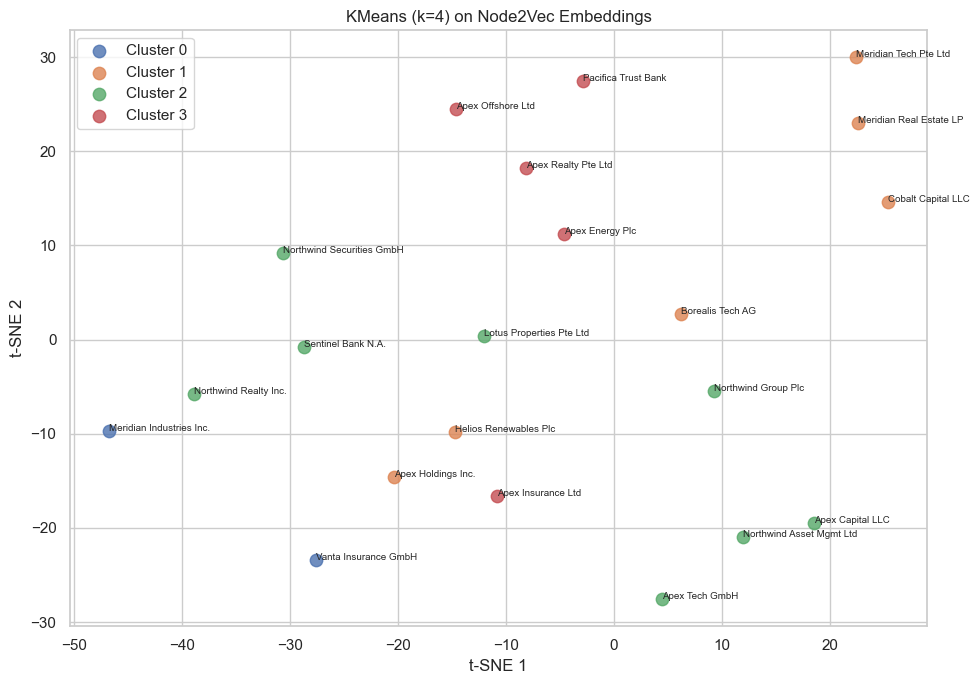

KMeans Cluster 0: ['Meridian Industries Inc.', 'Vanta Insurance GmbH']
KMeans Cluster 1: ['Apex Holdings Inc.', 'Meridian Real Estate LP', 'Meridian Tech Pte Ltd', 'Helios Renewables Plc', 'Borealis Tech AG', 'Cobalt Capital LLC']
KMeans Cluster 2: ['Apex Capital LLC', 'Apex Tech GmbH', 'Northwind Group Plc', 'Northwind Asset Mgmt Ltd', 'Northwind Securities GmbH', 'Northwind Realty Inc.', 'Sentinel Bank N.A.', 'Lotus Properties Pte Ltd']
KMeans Cluster 3: ['Apex Energy Plc', 'Apex Realty Pte Ltd', 'Apex Offshore Ltd', 'Apex Insurance Ltd', 'Pacifica Trust Bank']


In [91]:

# 5.3 KMeans clustering on embeddings
n_clusters = min(4, n_samples)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(embeddings_matrix)

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
embedding_df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 7))
for c in range(n_clusters):
    subset = embedding_df[embedding_df['kmeans_cluster'] == c]
    plt.scatter(subset['x'], subset['y'], s=80, label=f'Cluster {c}', alpha=0.8)
    for _, row in subset.iterrows():
        plt.annotate(row['name'], (row['x'], row['y']), fontsize=7)
plt.legend(); plt.title(f'KMeans (k={n_clusters}) on Node2Vec Embeddings')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.tight_layout(); plt.show()

# Cluster membership
for c in range(n_clusters):
    members = embedding_df[embedding_df['kmeans_cluster'] == c]['name'].tolist()
    print(f'KMeans Cluster {c}: {members}')


DBSCAN found 1 clusters (including noise), 21 noise points


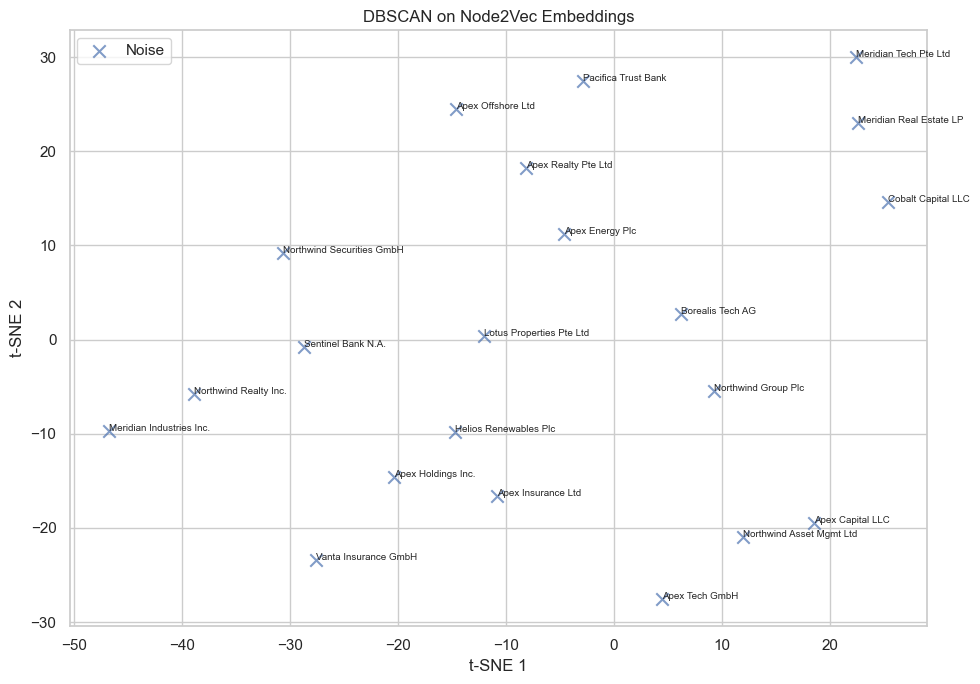

In [92]:

# 5.4 DBSCAN clustering — density-based
dbscan = DBSCAN(eps=1.2, min_samples=2)
embedding_df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_dbscan = embedding_df['dbscan_cluster'].nunique()
n_noise = (embedding_df['dbscan_cluster'] == -1).sum()
print(f'DBSCAN found {n_dbscan} clusters (including noise), {n_noise} noise points')

plt.figure(figsize=(10, 7))
for c in sorted(embedding_df['dbscan_cluster'].unique()):
    label = f'Noise' if c == -1 else f'Cluster {c}'
    subset = embedding_df[embedding_df['dbscan_cluster'] == c]
    plt.scatter(subset['x'], subset['y'], s=80, label=label, alpha=0.7,
                marker='x' if c == -1 else 'o')
    for _, row in subset.iterrows():
        plt.annotate(row['name'], (row['x'], row['y']), fontsize=7)
plt.legend(); plt.title('DBSCAN on Node2Vec Embeddings')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.tight_layout(); plt.show()


---
## 6. ML — Risk Classification (Random Forest)
Build a classifier to predict whether an entity is 'high risk' based on graph features.

In [93]:

# 6.1 Build feature matrix for ML classification
# Features: PageRank, Betweenness, embedding dims, degree
entity_features = q("""
MATCH (e:LegalEntity)
OPTIONAL MATCH (e)-[o:HAS_OWNERSHIP_IN]->()
OPTIONAL MATCH (e)-[l:LENDS_TO]->()
OPTIONAL MATCH (e)<-[li:LENDS_TO]-()
OPTIONAL MATCH (e)-[:INCORPORATED_IN]->(j)
RETURN e.name AS name,
       count(DISTINCT o) AS ownership_out,
       count(DISTINCT l) AS lending_out,
       count(DISTINCT li) AS lending_in,
       j.name AS jurisdiction
""")

# Merge with PageRank and Betweenness
features = entity_features.merge(pagerank_df.rename(columns={'score':'pagerank'}), on='name', how='left')
features = features.merge(between_df, on='name', how='left')
features = features.merge(embedding_df[['name','kmeans_cluster']], on='name', how='left')
features = features.fillna(0)

# Create risk label: high-degree + high-pagerank → 'high', else 'low'
median_pr = features['pagerank'].median()
features['risk_label'] = features.apply(
    lambda r: 'high' if (r['pagerank'] > median_pr and (r['ownership_out'] + r['lending_out']) > 1) else 'low',
    axis=1
)

print(f'Feature matrix: {features.shape}')
print(f'Risk distribution:\n{features["risk_label"].value_counts()}')
display(features.head(10))


Feature matrix: (21, 9)
Risk distribution:
risk_label
low     17
high     4
Name: count, dtype: int64


,name,ownership_out,lending_out,lending_in,jurisdiction,pagerank,betweenness,kmeans_cluster,risk_label
0,Apex Holdings Inc.,4,0,0,United States,0.8768,122.5,1,high
1,Apex Capital LLC,0,0,1,United States,0.1500,27.0,2,low
2,Apex Energy Plc,1,0,1,United Kingdom,0.1500,63.0,3,low
3,Apex Tech GmbH,0,0,0,Germany,0.1500,7.0,2,low
4,Apex Realty Pte Ltd,0,0,1,Singapore,0.1500,6.5,3,low
5,Apex Offshore Ltd,2,0,0,Cayman Islands,0.4050,89.5,3,high
6,Apex Insurance Ltd,2,0,0,United Kingdom,0.1500,46.0,3,low
7,Northwind Group Plc,3,0,0,United Kingdom,0.5325,102.5,2,high
8,Northwind Asset Mgmt Ltd,0,0,0,United Kingdom,0.1500,0.0,2,low
9,Northwind Securities GmbH,1,0,1,Germany,0.1500,74.0,2,low


=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

        high       1.00      1.00      1.00         1
         low       1.00      1.00      1.00         6

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



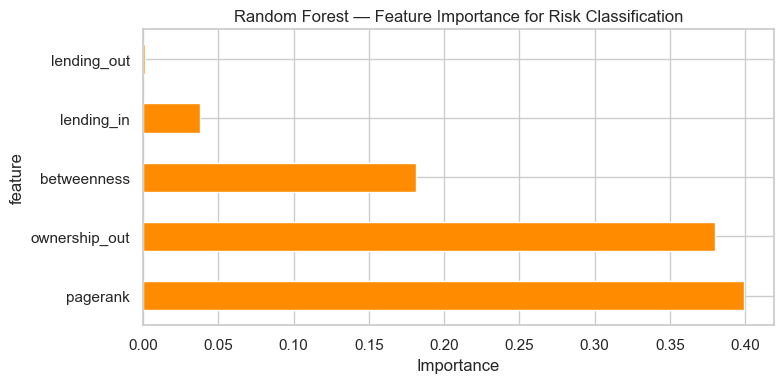

In [94]:

# 6.2 Random Forest Classification
feature_cols = ['ownership_out', 'lending_out', 'lending_in', 'pagerank', 'betweenness']
X = features[feature_cols].values
y = features['risk_label'].values

# Stratified split (small dataset — use 70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=3)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('=== Random Forest — Classification Report ===')
print(classification_report(y_test, y_pred, zero_division=0))

# Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

importance.plot.barh(x='feature', y='importance', color='darkorange', legend=False, figsize=(8, 4))
plt.title('Random Forest — Feature Importance for Risk Classification')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()


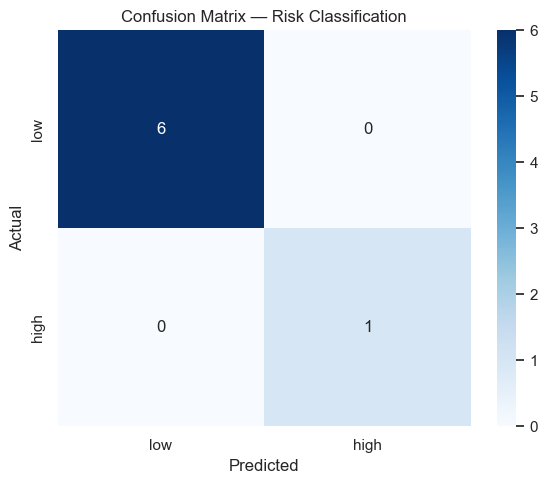

In [95]:

# 6.3 Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred, labels=['low', 'high'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['low', 'high'], yticklabels=['low', 'high'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Risk Classification')
plt.tight_layout(); plt.show()


---
## 7. GDS — Article Rank & Degree Centrality
Additional centrality measures for richer analysis.

In [96]:

# 7. Article Rank + Degree Centrality
article_rank_df = q("""
CALL gds.articleRank.stream('counterparty_ml', {
    maxIterations: 30,
    dampingFactor: 0.85
}) YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS n, score
RETURN n.name AS name, round(score * 10000) / 10000 AS articleRank
ORDER BY articleRank DESC
""")
print('=== Article Rank ===')
display(article_rank_df.head(10))

degree_df = q("""
CALL gds.degree.stream('counterparty_ml') YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS n, score
RETURN n.name AS name, score AS degree
ORDER BY degree DESC
""")
print('\n=== Degree Centrality ===')
display(degree_df.head(10))


=== Article Rank ===


,name,articleRank
0,Apex Holdings Inc.,0.4141
1,Northwind Group Plc,0.3750
2,Meridian Industries Inc.,0.3533
3,Apex Offshore Ltd,0.3004
4,Meridian Tech Pte Ltd,0.2832
5,Apex Tech GmbH,0.2534
6,Northwind Realty Inc.,0.2350
7,Cobalt Capital LLC,0.2314
8,Apex Capital LLC,0.2302
9,Apex Energy Plc,0.2302



=== Degree Centrality ===


,name,degree
0,Sentinel Bank N.A.,6.0
1,Pacifica Trust Bank,6.0
2,Apex Holdings Inc.,4.0
3,Apex Offshore Ltd,3.0
4,Apex Insurance Ltd,3.0
5,Northwind Group Plc,3.0
6,Meridian Industries Inc.,3.0
7,Apex Energy Plc,2.0
8,Northwind Securities GmbH,2.0
9,Helios Renewables Plc,2.0


---
## 8. PyVis — Interactive Community Graph Visualization
Visualize the graph colored by Louvain community with lending relationships.

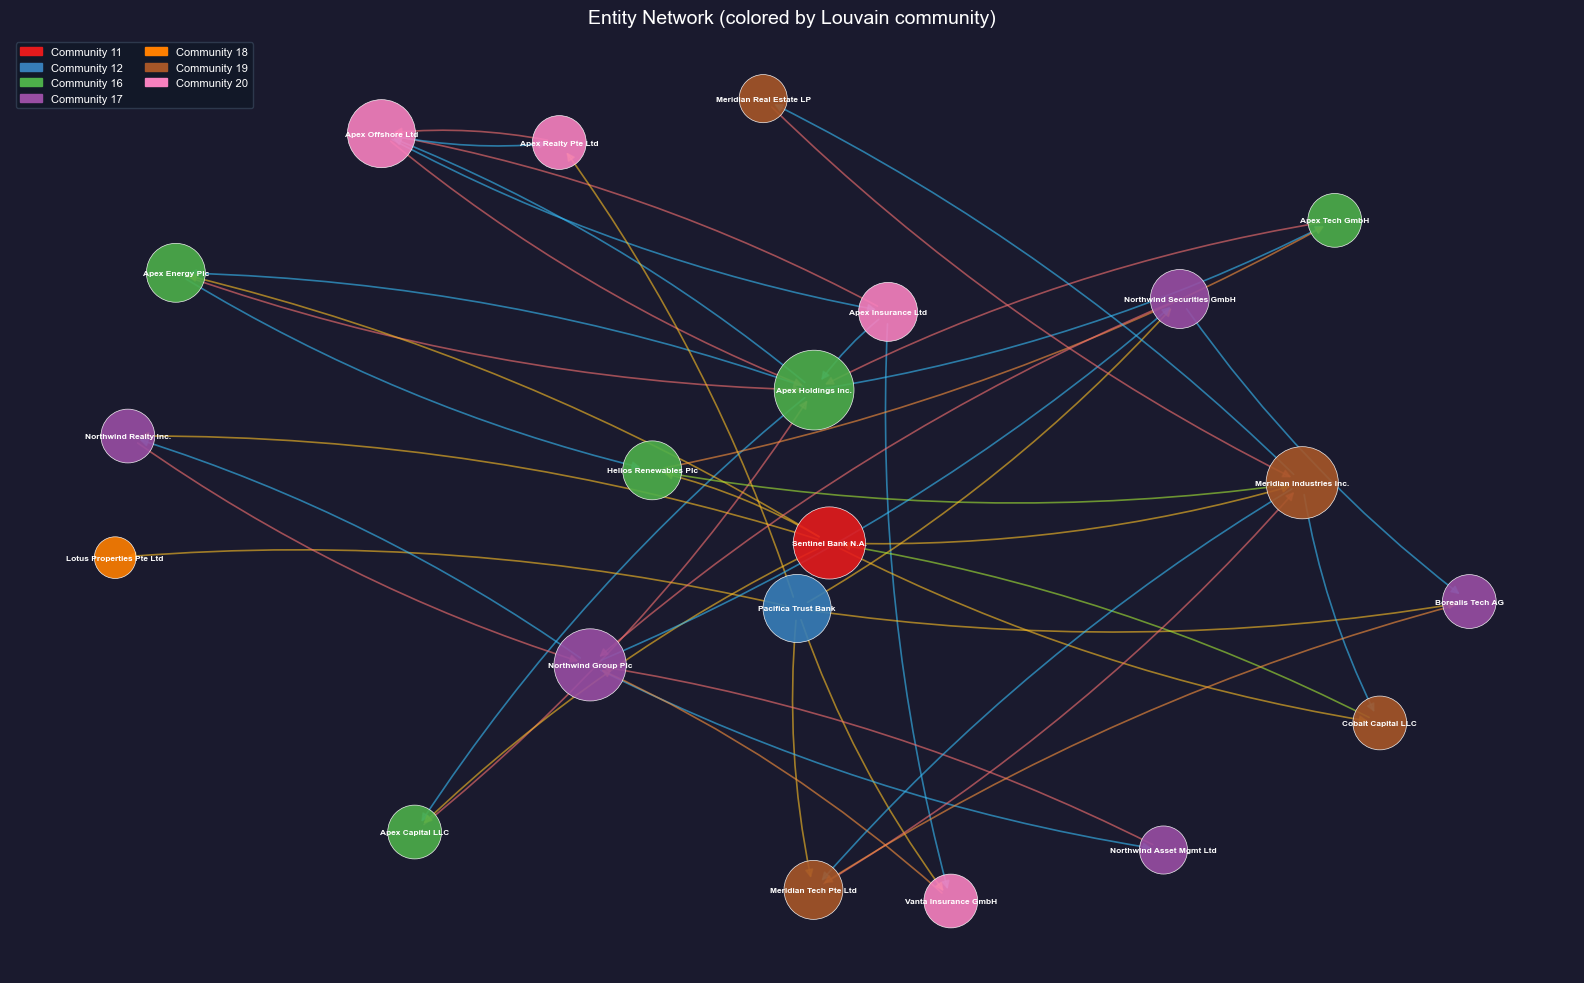

In [97]:
# 8. Community Graph — NetworkX + Matplotlib (colored by Louvain community)
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

edges_df = q("""
MATCH (a:LegalEntity)-[r]->(b:LegalEntity)
RETURN a.name AS source, type(r) AS rel, b.name AS target
""")

G_comm = nx.DiGraph()
community_map = dict(zip(louvain_df['name'], louvain_df['communityId']))
comm_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
               '#a65628', '#f781bf', '#999999', '#66c2a5', '#fc8d62']

# Get unique community IDs and assign color index
unique_comms = sorted(set(community_map.values()))
comm_to_idx = {c: i for i, c in enumerate(unique_comms)}

for _, row in edges_df.iterrows():
    if row['source'] in community_map and row['target'] in community_map:
        G_comm.add_edge(row['source'], row['target'], rel=row['rel'])

# Add isolated nodes from community map
for name in community_map:
    if name not in G_comm:
        G_comm.add_node(name)

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_facecolor('#1a1a2e')
fig.set_facecolor('#1a1a2e')

pos = nx.spring_layout(G_comm, k=2.2, iterations=80, seed=42)
node_colors = [comm_colors[comm_to_idx.get(community_map.get(n, 0), 0) % len(comm_colors)]
               for n in G_comm.nodes()]
node_sizes = [600 + G_comm.degree(n) * 300 for n in G_comm.nodes()]

nx.draw_networkx_nodes(G_comm, pos, node_color=node_colors, node_size=node_sizes,
                       alpha=0.9, edgecolors='white', linewidths=0.5, ax=ax)
nx.draw_networkx_labels(G_comm, pos, font_size=6, font_color='white', font_weight='bold', ax=ax)

# Color edges by relationship type
rel_edge_colors = {'HAS_OWNERSHIP_IN': '#38bdf8', 'HAS_CONTROLLING_PARTY': '#f87171',
                   'LENDS_TO': '#fbbf24', 'SUPPLIES_TO': '#fb923c', 'JOINT_VENTURE': '#a3e635'}
for u, v, d in G_comm.edges(data=True):
    ec = rel_edge_colors.get(d.get('rel', ''), '#555555')
    nx.draw_networkx_edges(G_comm, pos, edgelist=[(u,v)], edge_color=ec,
                           alpha=0.6, width=1.2, arrows=True, arrowsize=12,
                           connectionstyle='arc3,rad=0.08', ax=ax)

# Legend for communities
legend_patches = [mpatches.Patch(color=comm_colors[comm_to_idx[c] % len(comm_colors)],
                                 label=f'Community {c}')
                  for c in unique_comms]
ax.legend(handles=legend_patches, loc='upper left', fontsize=8, ncol=2,
          facecolor='#111827', edgecolor='#334155', labelcolor='white')
ax.set_title('Entity Network (colored by Louvain community)', color='white', fontsize=14, pad=10)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 9. PCA Analysis — Entity Feature Space
Reduce the multi-dimensional feature space and visualize entity clustering.

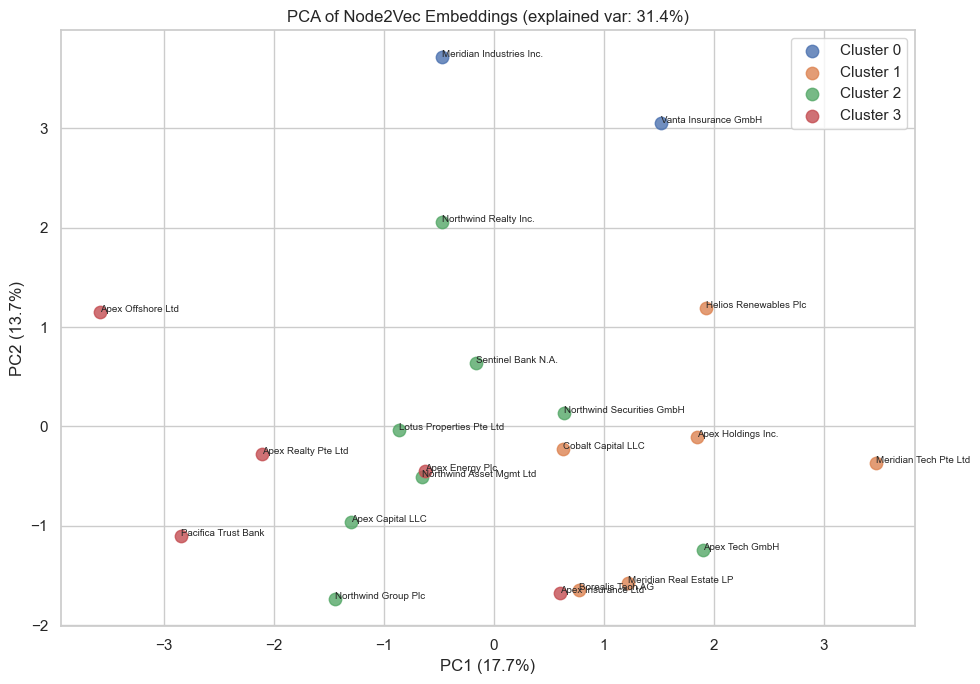

In [98]:

# 9. PCA Feature Space Analysis
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
for c in range(n_clusters):
    mask = embedding_df['kmeans_cluster'] == c
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1], s=80, label=f'Cluster {c}', alpha=0.8)
    for idx in np.where(mask)[0]:
        plt.annotate(embedding_df.iloc[idx]['name'], (pca_coords[idx, 0], pca_coords[idx, 1]), fontsize=7)

plt.title(f'PCA of Node2Vec Embeddings (explained var: {pca.explained_variance_ratio_.sum():.1%})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend(); plt.tight_layout(); plt.show()


---
## 10. Ontology Alignment — RDFLib ↔ Neo4j Cross-Reference
Compare the local RDFLib ontology view with what n10s loaded into Neo4j.

In [99]:

# 10. RDFLib ↔ Neo4j Ontology Alignment
# Load FIBO ontology subset via RDFLib
g = RDFGraph()
fibo_url = 'https://spec.edmcouncil.org/fibo/ontology/master/latest/BE/LegalEntities/LegalPersons/'
try:
    g.parse(fibo_url, format='xml')
    print(f'RDFLib loaded {len(g)} triples from FIBO LegalPersons')
except Exception as e:
    print(f'Could not fetch FIBO URL ({e}), using local ontology check...')
    # Fallback: compare labels from Neo4j
    g = None

# Get Neo4j ontology classes
neo4j_classes = q("MATCH (c:Class) RETURN c.name AS name ORDER BY c.name")
print(f'\nNeo4j has {len(neo4j_classes)} :Class nodes')
display(neo4j_classes.head(15))

if g is not None:
    # Extract OWL classes from RDFLib
    rdf_classes = set()
    for s in g.subjects(RDF.type, OWL.Class):
        name = str(s).split('/')[-1]
        if name:
            rdf_classes.add(name)
    print(f'\nRDFLib extracted {len(rdf_classes)} OWL classes')
    # Overlap
    neo4j_set = set(neo4j_classes['name'].tolist())
    overlap = neo4j_set & rdf_classes
    print(f'Overlap: {len(overlap)} classes present in both')


RDFLib loaded 185 triples from FIBO LegalPersons

Neo4j has 237 :Class nodes


,name
0,AccountingFramework
1,BoardAgreement
2,BoardAgreement
3,BusinessEntity
4,BusinessLicense
5,BusinessObjective
6,CharteredLegalPerson
7,ContractuallyCapableEntity
8,ConventionalStreetAddress
9,Date



RDFLib extracted 15 OWL classes
Overlap: 14 classes present in both


---
## 11. APOC — Virtual Graphs & Relationship Aggregation
Use APOC to build aggregated views of the counterparty network.

=== Cross-border Lending by Jurisdiction ===


,from_jur,to_jur,cross_border_links,total_exposure
0,Singapore,Germany,3,285.0
1,United States,United Kingdom,2,255.0
2,United States,None,0,0.0
3,United Kingdom,None,0,0.0
4,Germany,None,0,0.0
5,Singapore,None,0,0.0
6,Cayman Islands,None,0,0.0


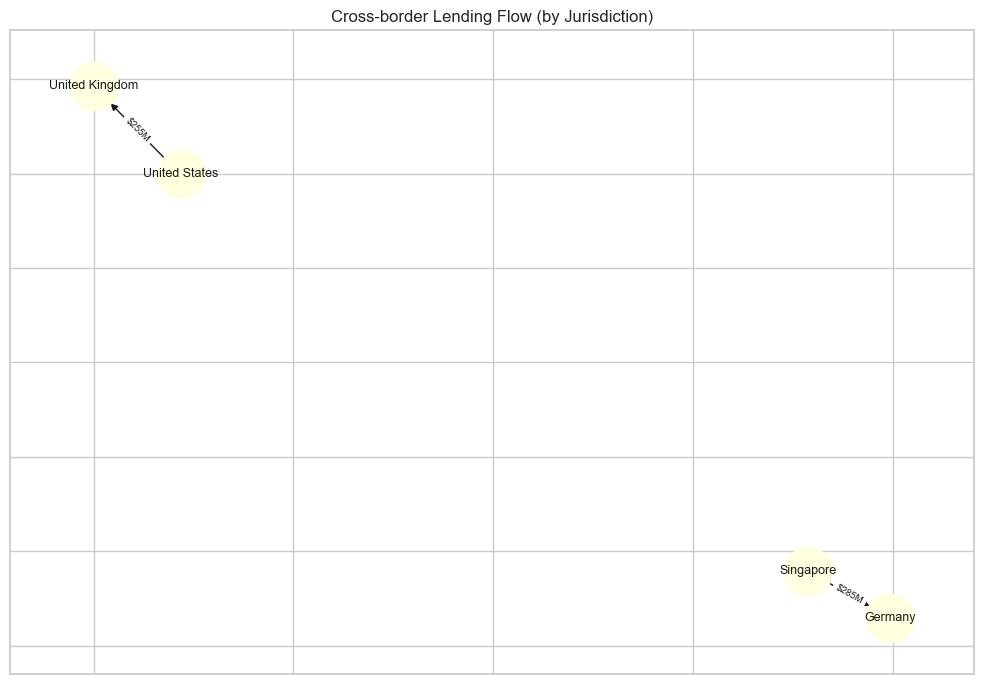

In [100]:

# 11. APOC Jurisdiction-Level Aggregation + NetworkX Flow
agg_df = q("""
MATCH (e:LegalEntity)-[:INCORPORATED_IN]->(j:Jurisdiction)
OPTIONAL MATCH (e)-[l:LENDS_TO]->(e2:LegalEntity)-[:INCORPORATED_IN]->(j2:Jurisdiction)
WHERE j <> j2
RETURN j.name AS from_jur, j2.name AS to_jur,
       count(l) AS cross_border_links,
       sum(l.exposure_musd) AS total_exposure
ORDER BY total_exposure DESC
""")
print('=== Cross-border Lending by Jurisdiction ===')
display(agg_df)

# NetworkX flow graph
G_flow = nx.DiGraph()
for _, row in agg_df.dropna().iterrows():
    G_flow.add_edge(row['from_jur'], row['to_jur'],
                    weight=row['total_exposure'],
                    links=row['cross_border_links'])

if G_flow.number_of_edges() > 0:
    pos = nx.spring_layout(G_flow, seed=42)
    plt.figure(figsize=(10, 7))
    nx.draw_networkx(G_flow, pos, with_labels=True, node_size=1200,
                     node_color='lightyellow', font_size=9, arrows=True)
    edge_labels = nx.get_edge_attributes(G_flow, 'weight')
    edge_labels = {k: f'${v:.0f}M' for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G_flow, pos, edge_labels, font_size=7)
    plt.title('Cross-border Lending Flow (by Jurisdiction)')
    plt.tight_layout(); plt.show()
else:
    print('No cross-border lending links found.')


---
## 12. Contagion Simulation — Cascade & Stress Test
Simulate what happens when an entity defaults: trace the cascade through ownership and lending.

Simulating contagion from: Apex Holdings Inc.
Entities affected within 4 hops: 18


,affected_entity,hops
0,Apex Capital LLC,1
1,Apex Energy Plc,1
2,Apex Tech GmbH,1
3,Apex Offshore Ltd,1
4,Helios Renewables Plc,2
5,Apex Realty Pte Ltd,2
6,Apex Insurance Ltd,2
7,Apex Energy Plc,3
8,Apex Tech GmbH,3
9,Apex Offshore Ltd,3


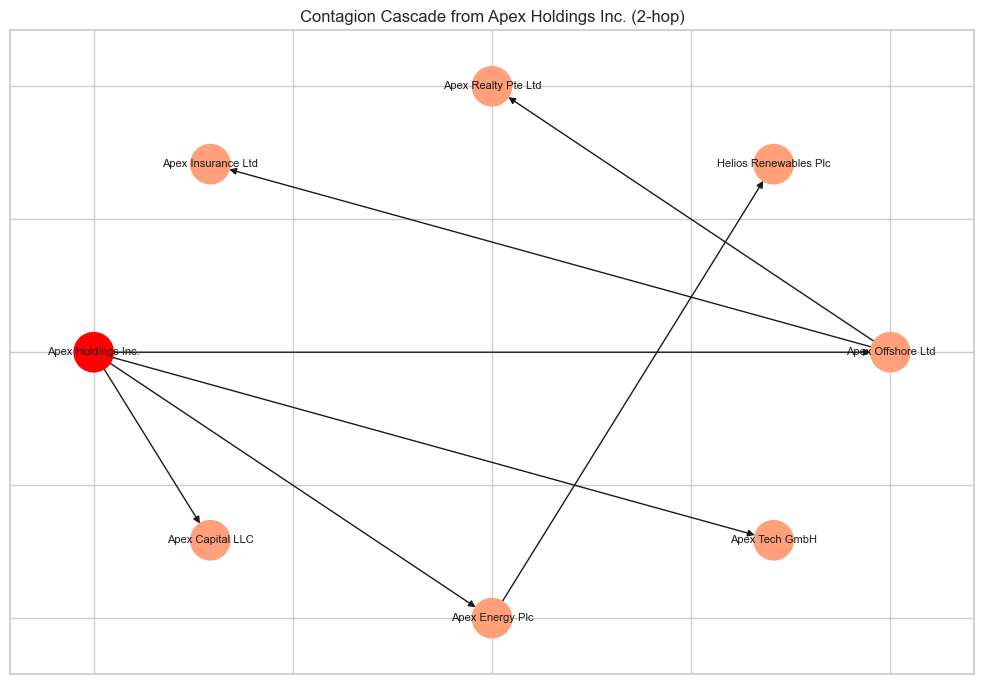

In [101]:

# 12. Contagion Cascade Simulation
# Simulate: if the highest PageRank entity defaults, who is affected?
top_entity = pagerank_df.iloc[0]['name']
print(f'Simulating contagion from: {top_entity}')

cascade = q("""
MATCH path = (start:LegalEntity {name: $seed})-[:HAS_CONTROLLING_PARTY|HAS_OWNERSHIP_IN|LENDS_TO*1..4]->(affected:LegalEntity)
WHERE affected <> start
RETURN DISTINCT affected.name AS affected_entity, length(path) AS hops
ORDER BY hops
""", seed=top_entity)
print(f'Entities affected within 4 hops: {len(cascade)}')
display(cascade)

# Visualize cascade
if len(cascade) > 0:
    G_casc = nx.DiGraph()
    G_casc.add_node(top_entity)
    for _, row in cascade.iterrows():
        G_casc.add_edge(top_entity if row['hops'] == 1 else '...', row['affected_entity'])

    # Better: rebuild from actual paths
    cascade_edges = q("""
    MATCH (start:LegalEntity {name: $seed})-[r:HAS_CONTROLLING_PARTY|HAS_OWNERSHIP_IN|LENDS_TO]->(next:LegalEntity)
    RETURN start.name AS src, next.name AS tgt, type(r) AS rel
    UNION
    MATCH (start:LegalEntity {name: $seed})-[:HAS_CONTROLLING_PARTY|HAS_OWNERSHIP_IN|LENDS_TO]->(mid:LegalEntity)
          -[r2:HAS_CONTROLLING_PARTY|HAS_OWNERSHIP_IN|LENDS_TO]->(next2:LegalEntity)
    WHERE next2 <> start
    RETURN mid.name AS src, next2.name AS tgt, type(r2) AS rel
    """, seed=top_entity)

    G_casc = nx.DiGraph()
    for _, row in cascade_edges.iterrows():
        G_casc.add_edge(row['src'], row['tgt'], label=row['rel'])

    pos = nx.shell_layout(G_casc)
    plt.figure(figsize=(10, 7))
    node_colors = ['red' if n == top_entity else 'lightsalmon' for n in G_casc.nodes()]
    nx.draw_networkx(G_casc, pos, node_color=node_colors, node_size=800,
                     font_size=8, arrows=True)
    plt.title(f'Contagion Cascade from {top_entity} (2-hop)')
    plt.tight_layout(); plt.show()


---
## 13. GDS Write-Back & Summary
Write computed analytics back to Neo4j for use in downstream applications.

In [102]:

# 13.1 Write-back GDS results to Neo4j
q("""
CALL gds.pageRank.write('counterparty_ml', {
    writeProperty: 'systemicScore',
    relationshipTypes: ['HAS_CONTROLLING_PARTY'],
    maxIterations: 30,
    dampingFactor: 0.85
}) YIELD nodePropertiesWritten
RETURN nodePropertiesWritten
""")

q("""
CALL gds.louvain.write('counterparty_ml', {
    writeProperty: 'communityId',
    relationshipTypes: ['HAS_OWNERSHIP_IN'],
    relationshipWeightProperty: 'weight'
}) YIELD communityCount, modularity
RETURN communityCount, modularity
""")

q("""
CALL gds.betweenness.write('counterparty_ml', {
    writeProperty: 'betweennessCentrality'
}) YIELD nodePropertiesWritten
RETURN nodePropertiesWritten
""")

print('GDS results written back: systemicScore, communityId, betweennessCentrality')

# Final summary
summary = q("""
MATCH (e:LegalEntity)
RETURN e.name AS name,
       e.systemicScore AS pageRank,
       e.communityId AS community,
       e.betweennessCentrality AS betweenness
ORDER BY e.systemicScore DESC
""")
display(summary)


GDS results written back: systemicScore, communityId, betweennessCentrality


,name,pageRank,community,betweenness
0,Apex Holdings Inc.,0.87675,16,122.5
1,Northwind Group Plc,0.53250,17,102.5
2,Apex Offshore Ltd,0.40500,20,89.5
3,Meridian Industries Inc.,0.40500,19,154.0
4,Apex Capital LLC,0.15000,16,27.0
5,Apex Energy Plc,0.15000,16,63.0
6,Apex Tech GmbH,0.15000,16,7.0
7,Apex Realty Pte Ltd,0.15000,20,6.5
8,Apex Insurance Ltd,0.15000,20,46.0
9,Northwind Asset Mgmt Ltd,0.15000,17,0.0


In [103]:

# 13.2 Final Analytics Summary
print('='*60)
print('   FIBO Advanced Analytics — Summary')
print('='*60)
print(f'\n  Entities analyzed:          {len(features)}')
print(f'  GDS Communities (Louvain):  {louvain_df["communityId"].nunique()}')
print(f'  Connected Components (WCC): {wcc_df["componentId"].nunique()}')
print(f'  KMeans clusters:            {n_clusters}')
print(f'  DBSCAN clusters:            {n_dbscan - 1} (+{n_noise} noise)')
print(f'  Cross-border links:         {len(agg_df.dropna())}')
print(f'  Contagion reach (from top): {len(cascade)} entities')
print(f'  RF accuracy:                {(y_pred == y_test).mean():.1%}')
print(f'\n  Top 3 systemic entities:')
for _, row in pagerank_df.head(3).iterrows():
    print(f'    • {row["name"]}: {row["score"]:.4f}')
print('\n' + '='*60)


   FIBO Advanced Analytics — Summary

  Entities analyzed:          21
  GDS Communities (Louvain):  7
  Connected Components (WCC): 6
  KMeans clusters:            4
  DBSCAN clusters:            0 (+21 noise)
  Cross-border links:         2
  Contagion reach (from top): 18 entities
  RF accuracy:                100.0%

  Top 3 systemic entities:
    • Apex Holdings Inc.: 0.8768
    • Northwind Group Plc: 0.5325
    • Apex Offshore Ltd: 0.4050



In [104]:

# Cleanup
try:
    q("CALL gds.graph.drop('counterparty_ml') YIELD graphName RETURN graphName")
    print('GDS projection dropped.')
except:
    pass
driver.close()
print('Neo4j driver closed.')


GDS projection dropped.
Neo4j driver closed.
